In [30]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt

In [26]:
def median_of_posterior(mean, std):
    """
    Calculate the median of posterior distribution, with likelihood function being a normal distribution
    and a non-negative prior.

    Parameters:
    mean (float): The mean of the normal distribution.
    std (float): The standard deviation of the normal distribution.

    Returns:
    float: The median of the normal distribution.
    """

    d_to_zero = mean / std
    cdf_zero = norm.cdf(-d_to_zero)
    re_norm_const = 1 - cdf_zero

    def posterior_cdf(x):
        if x < 0:
            return 0.0
        return (norm.cdf(x) - cdf_zero) / re_norm_const

    # Use binary search to find the median
    func = lambda x: posterior_cdf(x) - 0.5
    # return root_scalar(func, bracket=[0, 10], method='bisect')
    root = root_scalar(func, bracket=[0, 10], method='bisect').root
    return mean + std * root


In [32]:
xx = np.linspace(0, 5, 100)
yy = np.array([median_of_posterior(x, 1) for x in xx])

In [70]:
median_lst = []

for _ in range(1000):
    rv_norm = norm.rvs(size=100000, loc=0, scale=1)
    median_lst.append(np.median(rv_norm[rv_norm>=0]))


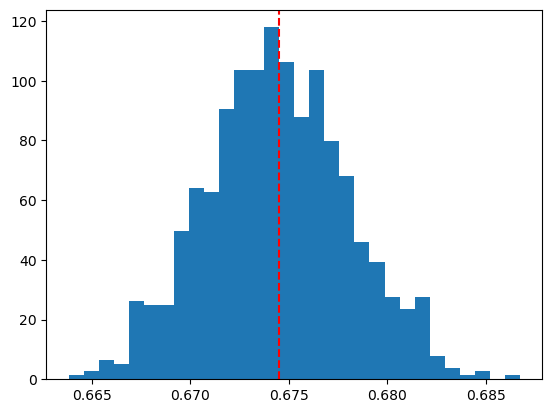

In [71]:
plt.hist(median_lst, bins=30, density=True);
plt.axvline(median_of_posterior(0, 1), color='r', linestyle='--')

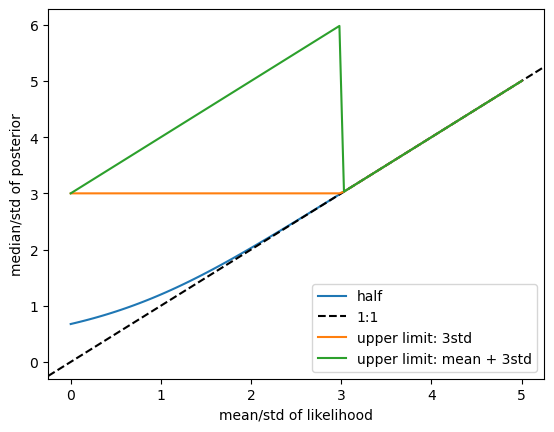

In [81]:
plt.plot(xx, yy, label='half')
plt.axline((0, 0), (1, 1), color='k', linestyle='--', label='1:1')
plt.plot(xx, [x if x > 3 else 3 for x in xx], label='upper limit: 3std')
plt.plot(xx, [x if x > 3 else x + 3 for x in xx], label='upper limit: mean + 3std')
plt.xlabel('mean/std of likelihood')
plt.ylabel('median/std of posterior')
plt.legend()

In [74]:
median_of_posterior(0, 1), median_of_posterior(0, 10)

(0.6744897501960168, 6.744897501960168)